# 01 — Exploratory Data Analysis

Load raw DoorDash deliveries, build the target, inspect schema, missingness, distributions, correlations.

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
pd.set_option('display.max_columns', 60)

## Task 1: Load dataset

In [13]:
df = pd.read_csv('../data/historical_data.csv', parse_dates=['created_at', 'actual_delivery_time'])
print('shape:', df.shape)
df.head()

shape: (197428, 16)


,market_id,created_at,actual_delivery_time,store_id,store_primary_category,order_protocol,total_items,subtotal,num_distinct_items,min_item_price,max_item_price,total_onshift_dashers,total_busy_dashers,total_outstanding_orders,estimated_order_place_duration,estimated_store_to_consumer_driving_duration
0,1.0,2015-02-06 22:24:17,2015-02-06 23:27:16,1845,american,1.0,4,3441,4,557,1239,33.0,14.0,21.0,446,861.0
1,2.0,2015-02-10 21:49:25,2015-02-10 22:56:29,5477,mexican,2.0,1,1900,1,1400,1400,1.0,2.0,2.0,446,690.0
2,3.0,2015-01-22 20:39:28,2015-01-22 21:09:09,5477,NaN,1.0,1,1900,1,1900,1900,1.0,0.0,0.0,446,690.0
3,3.0,2015-02-03 21:21:45,2015-02-03 22:13:00,5477,NaN,1.0,6,6900,5,600,1800,1.0,1.0,2.0,446,289.0
4,3.0,2015-02-15 02:40:36,2015-02-15 03:20:26,5477,NaN,1.0,3,3900,3,1100,1600,6.0,6.0,9.0,446,650.0


In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 197428 entries, 0 to 197427
Data columns (total 16 columns):
 #   Column                                        Non-Null Count   Dtype         
---  ------                                        --------------   -----         
 0   market_id                                     196441 non-null  float64       
 1   created_at                                    197428 non-null  datetime64[ns]
 2   actual_delivery_time                          197421 non-null  datetime64[ns]
 3   store_id                                      197428 non-null  int64         
 4   store_primary_category                        192668 non-null  object        
 5   order_protocol                                196433 non-null  float64       
 6   total_items                                   197428 non-null  int64         
 7   subtotal                                      197428 non-null  int64         
 8   num_distinct_items                            197428 n

## Task 2: Create target — `delivery_duration` (seconds)

`delivery_duration = actual_delivery_time - created_at`

In [15]:
df['delivery_duration'] = (df['actual_delivery_time'] - df['created_at']).dt.total_seconds()
df['delivery_duration'].describe()

count    1.974210e+05
mean     2.908257e+03
std      1.922961e+04
min      1.010000e+02
25%      2.104000e+03
50%      2.660000e+03
75%      3.381000e+03
max      8.516859e+06
Name: delivery_duration, dtype: float64

## Task 3: Missing-value summary

In [16]:
(df.isna().mean() * 100).round(2).sort_values(ascending=False).rename('% missing').to_frame()

,% missing
total_outstanding_orders,8.24
total_busy_dashers,8.24
total_onshift_dashers,8.24
store_primary_category,2.41
market_id,0.50
order_protocol,0.50
estimated_store_to_consumer_driving_duration,0.27
max_item_price,0.00
estimated_order_place_duration,0.00
num_distinct_items,0.00


## Task 4: Target distribution

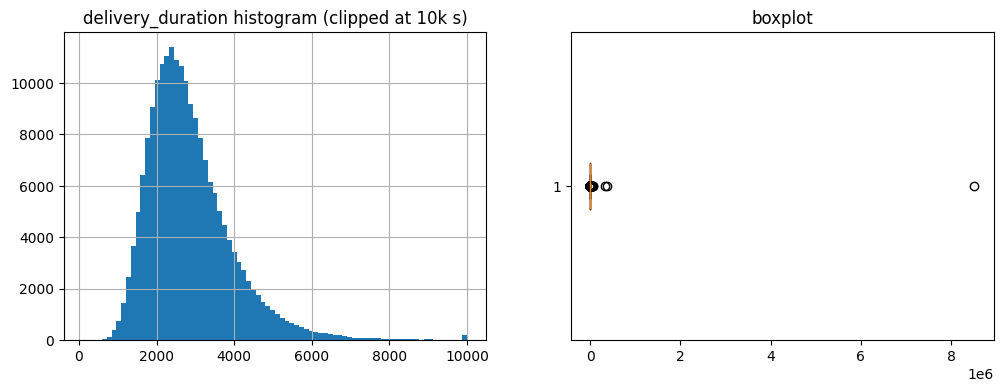

In [17]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
df['delivery_duration'].clip(0, 10000).hist(bins=80, ax=ax[0])
ax[0].set_title('delivery_duration histogram (clipped at 10k s)')
ax[1].boxplot(df['delivery_duration'].dropna(), vert=False)
ax[1].set_title('boxplot')
plt.show()

Heavy right tail. We'll drop ETAs < 60s or > 3h downstream as data-quality artefacts.

## Task 5: Feature distributions

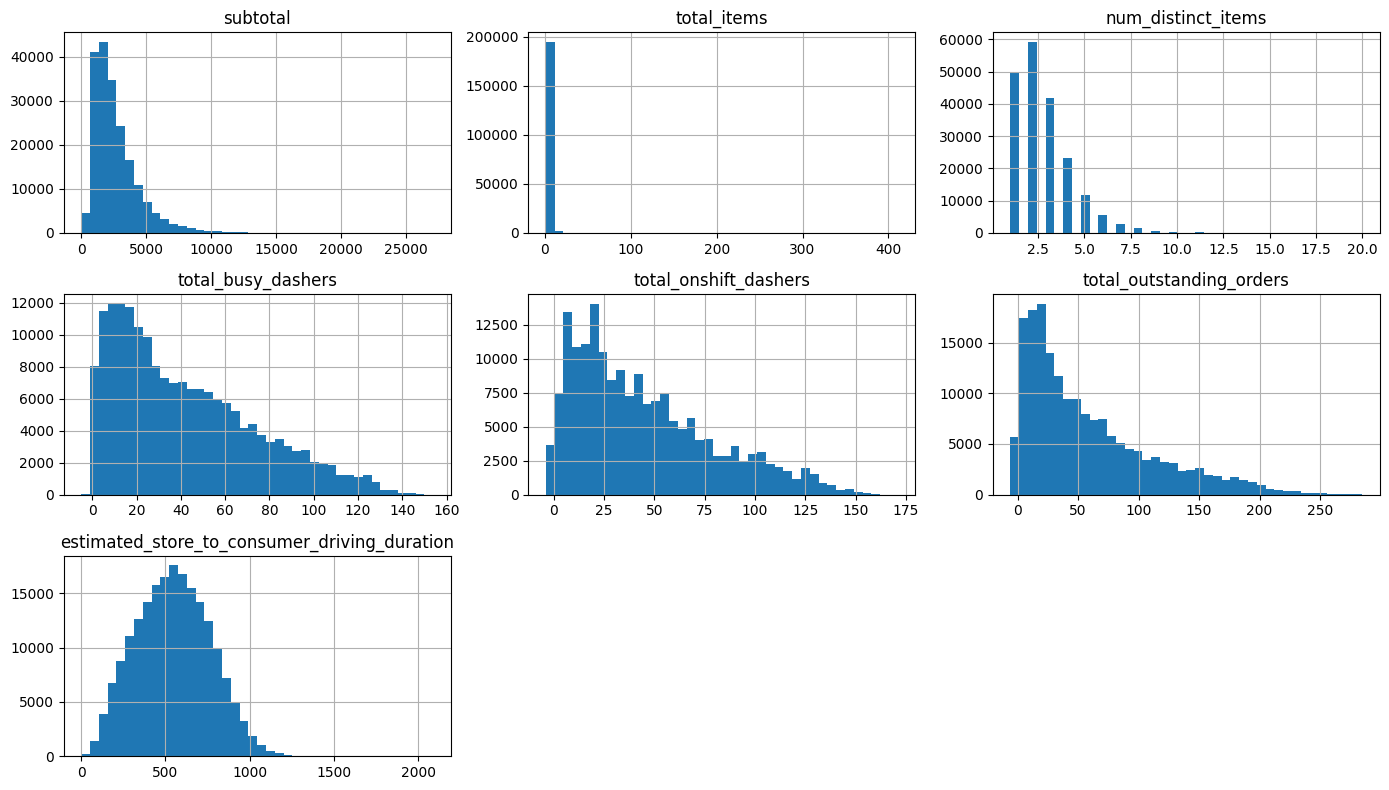

In [18]:
cols = ['subtotal','total_items','num_distinct_items',
        'total_busy_dashers','total_onshift_dashers','total_outstanding_orders',
        'estimated_store_to_consumer_driving_duration']
df[cols].hist(bins=40, figsize=(14, 8))
plt.tight_layout(); plt.show()

## Task 6: Correlation heatmap

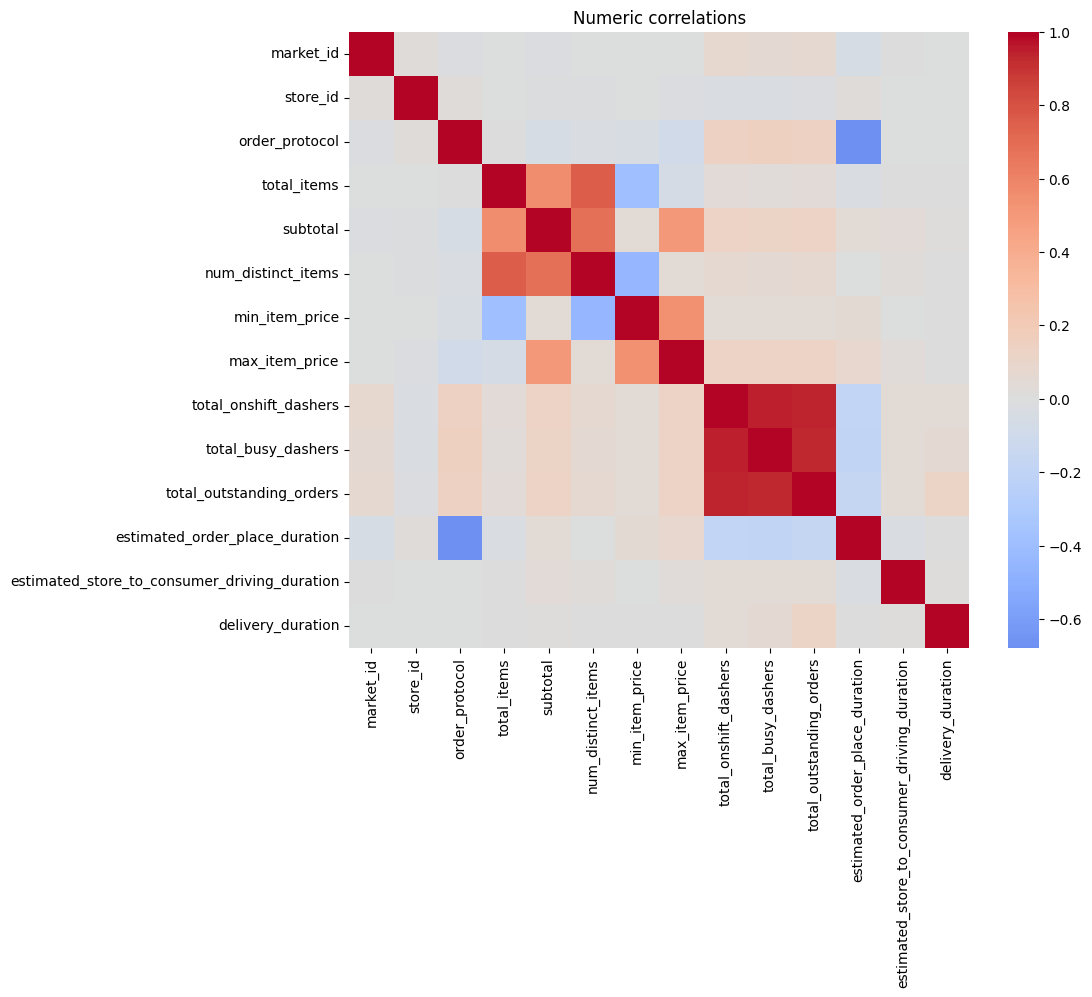

In [19]:
num = df.select_dtypes(include='number')
plt.figure(figsize=(10, 8))
sns.heatmap(num.corr(), annot=False, cmap='coolwarm', center=0)
plt.title('Numeric correlations')
plt.show()

In [20]:
# Direct correlations with the target
num.corr()['delivery_duration'].sort_values(ascending=False)

delivery_duration                               1.000000
total_outstanding_orders                        0.122294
total_busy_dashers                              0.060641
total_onshift_dashers                           0.046972
estimated_store_to_consumer_driving_duration    0.012198
subtotal                                        0.011200
max_item_price                                  0.009409
estimated_order_place_duration                  0.009200
num_distinct_items                              0.006741
total_items                                     0.004905
min_item_price                                  0.004762
store_id                                       -0.000414
market_id                                      -0.005784
order_protocol                                 -0.006660
Name: delivery_duration, dtype: float64

## Task 7: EDA Summary

- **Top correlates** with `delivery_duration`: `estimated_store_to_consumer_driving_duration`, plus marketplace load (`total_outstanding_orders`, `total_busy_dashers`).
- **Missingness** concentrated in dasher columns and `store_primary_category`.
- **Outliers**: long tail above 1 h; ETAs above 3 h or below 60 s look like data-quality issues — will be dropped.
- **Leakage concerns**: `actual_delivery_time` is post-hoc; we only use `created_at`-time signals for prediction.